# Air Quality Prediction & Risk Classification System

**Goal:** Build a system that uses 3 machine learning models to analyze air pollution data:
1. **Regression** — Predict the numeric AQI value
2. **Classification** — Classify the risk level (Safe / Moderate / Dangerous)
3. **Clustering** — Group cities by pollution patterns (unsupervised)

**Dataset:** [Global Air Pollution Dataset — Kaggle](https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset)

---

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, classification_report,
    silhouette_score, ConfusionMatrixDisplay
)

from xgboost import XGBRegressor
import joblib, os

print('Libraries loaded successfully')

Libraries loaded successfully



## Load the Data


In [2]:
# Read the CSV file into a DataFrame
df = pd.read_csv('global air pollution dataset.csv')

print(f'Shape  : {df.shape}')       # number of rows and columns
print(f'Columns: {list(df.columns)}')
df.head()

Shape  : (23463, 12)
Columns: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good



## Exploratory Data Analysis (EDA)



In [3]:
# Basic statistics for all numeric columns
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [4]:
# Check for missing values
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

Country    427
City         1
dtype: int64


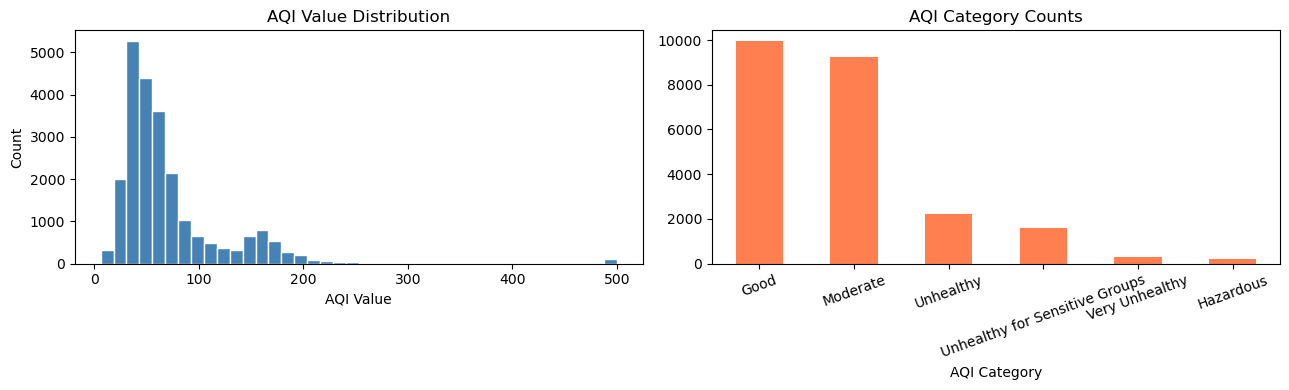

In [5]:
# Plot 1: AQI value distribution and category counts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: how AQI values are spread across the dataset
axes[0].hist(df['AQI Value'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('AQI Value Distribution')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Count')

# Right: how many records fall in each AQI category
df['AQI Category'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('AQI Category Counts')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

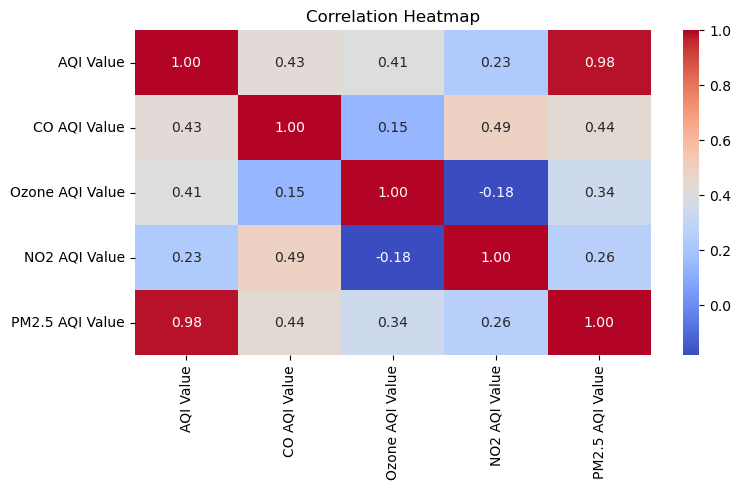

In [6]:
# Plot 2: Correlation heatmap
# Shows how strongly each pollutant is related to the overall AQI value
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

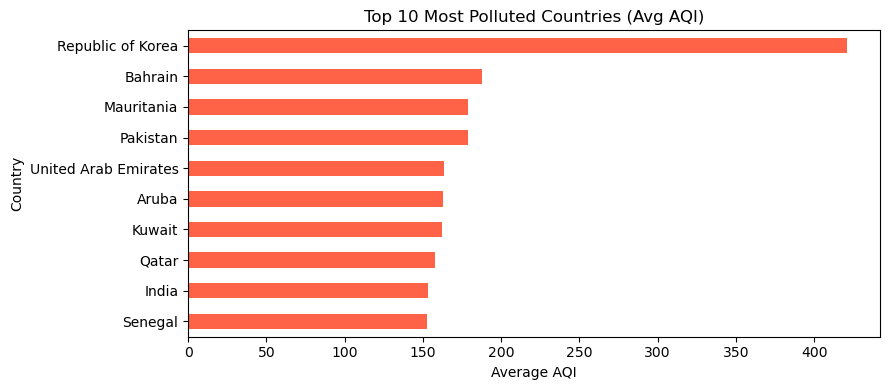

In [7]:
# Plot 3: Top 10 most polluted countries by average AQI
top10 = df.groupby('Country')['AQI Value'].mean().sort_values(ascending=False).head(10)

top10.plot(kind='barh', color='tomato', figsize=(9, 4))
plt.title('Top 10 Most Polluted Countries (Avg AQI)')
plt.xlabel('Average AQI')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Data Preprocessing

We clean the dataset and prepare it for modeling:
- Remove rows with missing target values
- Fill remaining missing values with the median
- Remove duplicate rows
- Remove extreme outliers using the IQR method
- Create a new feature: **Risk Level** (our classification target)

In [8]:
df_clean = df.copy()

# Drop rows where AQI Value is missing (it is our main target)
df_clean.dropna(subset=['AQI Value'], inplace=True)

# Fill missing values in numeric columns with the column median
for col in df_clean.select_dtypes(include=np.number).columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Remove duplicate rows
df_clean.drop_duplicates(inplace=True)

# Remove extreme outliers using IQR (keep values within 3 * IQR of the quartiles)
Q1, Q3 = df_clean['AQI Value'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_clean = df_clean[
    (df_clean['AQI Value'] >= Q1 - 3 * IQR) &
    (df_clean['AQI Value'] <= Q3 + 3 * IQR)
]

print(f'Clean dataset size: {df_clean.shape}')

Clean dataset size: (22974, 12)


In [9]:
# Create the Risk Level column — this will be the target for classification
def assign_risk(aqi):
    if aqi <= 100:   return 'Safe'
    elif aqi <= 200: return 'Moderate'
    else:            return 'Dangerous'

df_clean['Risk Level'] = df_clean['AQI Value'].apply(assign_risk)

print('Risk Level distribution:')
print(df_clean['Risk Level'].value_counts())

Risk Level distribution:
Risk Level
Safe        19219
Moderate     3755
Name: count, dtype: int64


In [10]:
# Define features and targets
feature_cols = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
feature_cols = [c for c in feature_cols if c in df_clean.columns]  # keep only existing columns

X       = df_clean[feature_cols]   # input features (same for all models)
y_reg   = df_clean['AQI Value']    # regression target  (numeric)
y_class = df_clean['Risk Level']   # classification target (Safe/Moderate/Dangerous)

# Split into training (80%) and test (20%) sets
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg,   test_size=0.2, random_state=42)
_,       _,      y_cls_train, y_cls_test  = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Scale features so that all columns have a similar range
# We fit the scaler only on training data, then apply it to test data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 18379
Test samples     : 4595



## Model 1: Regression (Predict AQI Value)

**Goal:** Predict the exact numeric AQI value given the four pollutant readings.

We train 3 models and compare them using:
- **R²** — how well the model explains the variance (closer to 1.0 is better)
- **MAE** — average prediction error in AQI units (lower is better)

In [11]:
# Train all three regression models and record their scores
reg_models = {
    'Linear Regression':       LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor':       XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_sc, y_reg_train)
    preds = model.predict(X_test_sc)
    r2  = r2_score(y_reg_test, preds)
    mae = mean_absolute_error(y_reg_test, preds)
    reg_results[name] = {'R2': r2, 'MAE': mae, 'model': model, 'preds': preds}
    print(f'{name:30s} | R2: {r2:.4f} | MAE: {mae:.2f}')

# Pick the model with the highest R2 score
best_reg_name = max(reg_results, key=lambda n: reg_results[n]['R2'])
print(f'\nBest model: {best_reg_name}')

Linear Regression              | R2: 0.9737 | MAE: 4.48
Random Forest Regressor        | R2: 1.0000 | MAE: 0.04
XGBoost Regressor              | R2: 0.9999 | MAE: 0.12

Best model: Random Forest Regressor


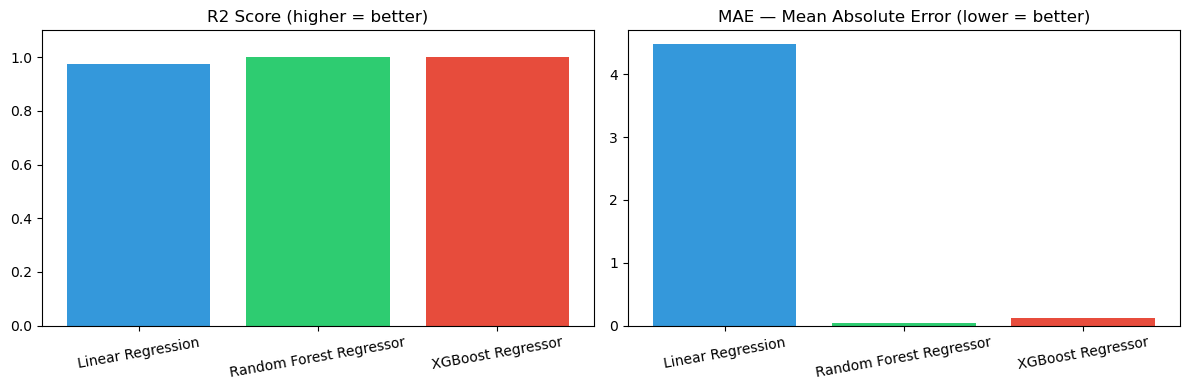

In [12]:
# Compare all regression models visually
names = list(reg_results.keys())
colors = ['#3498DB', '#2ECC71', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(names, [reg_results[n]['R2']  for n in names], color=colors)
axes[0].set_title('R2 Score (higher = better)')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(names, [reg_results[n]['MAE'] for n in names], color=colors)
axes[1].set_title('MAE — Mean Absolute Error (lower = better)')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

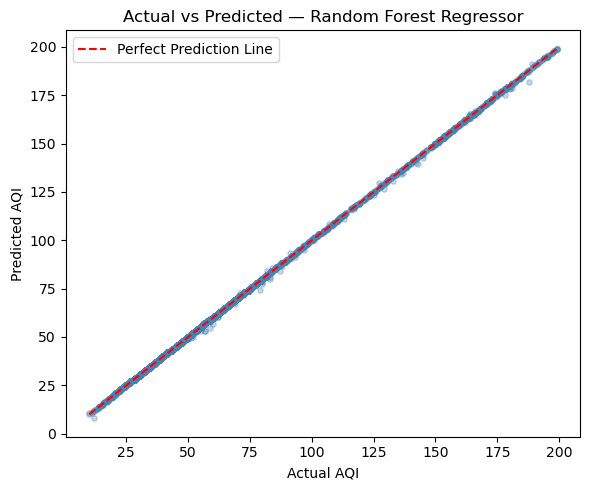

In [13]:
# Actual vs Predicted scatter plot for the best model
# Points close to the red line mean accurate predictions
best_preds = reg_results[best_reg_name]['preds']

plt.figure(figsize=(6, 5))
plt.scatter(y_reg_test, best_preds, alpha=0.3, s=15, color='steelblue')
mn, mx = y_reg_test.min(), y_reg_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect Prediction Line')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.show()


## Model 2: Classification (Risk Level)

**Goal:** Classify each air quality reading into one of three risk levels.

We use **Accuracy** as the main metric — the percentage of correctly classified samples.

In [14]:
# Encode string labels into numbers (Safe=2, Moderate=1, Dangerous=0 — sorted alphabetically)
le = LabelEncoder()
y_cls_train_enc = le.fit_transform(y_cls_train)
y_cls_test_enc  = le.transform(y_cls_test)
print('Classes:', list(le.classes_))

# Train all three classifiers
clf_models = {
    'Logistic Regression':      LogisticRegression(max_iter=500, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                      SVC(kernel='rbf', random_state=42)
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_sc, y_cls_train_enc)
    preds = model.predict(X_test_sc)
    acc = accuracy_score(y_cls_test_enc, preds)
    clf_results[name] = {'accuracy': acc, 'model': model, 'preds': preds}
    print(f'{name:28s} | Accuracy: {acc:.4f}')

best_clf_name = max(clf_results, key=lambda n: clf_results[n]['accuracy'])
print(f'\nBest model: {best_clf_name}')

Classes: ['Moderate', 'Safe']
Logistic Regression          | Accuracy: 0.9928
Random Forest Classifier     | Accuracy: 1.0000
SVM                          | Accuracy: 0.9965

Best model: Random Forest Classifier


In [15]:
# Detailed classification report for the best model
# Shows precision, recall, and F1-score per class
print(classification_report(
    y_cls_test_enc,
    clf_results[best_clf_name]['preds'],
    target_names=le.classes_
))

              precision    recall  f1-score   support

    Moderate       1.00      1.00      1.00       737
        Safe       1.00      1.00      1.00      3858

    accuracy                           1.00      4595
   macro avg       1.00      1.00      1.00      4595
weighted avg       1.00      1.00      1.00      4595



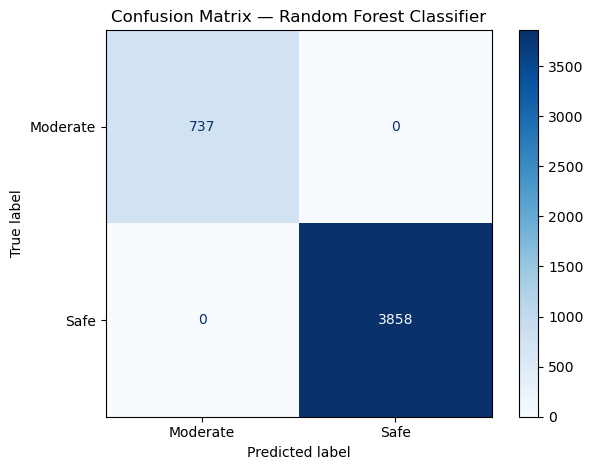

In [16]:
# Confusion Matrix — shows how many samples were correctly or incorrectly classified
ConfusionMatrixDisplay.from_predictions(
    y_cls_test_enc,
    clf_results[best_clf_name]['preds'],
    display_labels=le.classes_,
    cmap='Blues'
)
plt.title(f'Confusion Matrix — {best_clf_name}')
plt.tight_layout()
plt.show()


## Model 3: K-Means Clustering (Unsupervised)

**Goal:** Discover natural groupings in the pollution data — without using any labels.

We use the **Elbow Method** and **Silhouette Score** to find the best number of clusters (K):
- **Inertia (Elbow)** — lower means tighter clusters; we look for where the curve bends
- **Silhouette Score** — higher means clusters are better separated (range: -1 to 1)

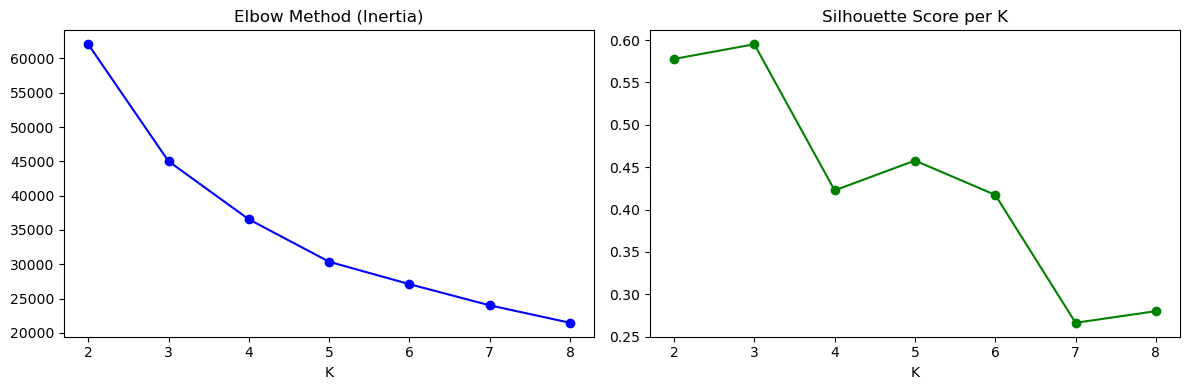

Best K: 3


In [17]:
# Scale the full dataset (not just train/test) for clustering
X_all_sc = scaler.transform(X)

# Try K from 2 to 8 and record inertia and silhouette score for each
inertias, sil_scores, K_range = [], [], range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_all_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_all_sc, km.labels_))

# Plot both metrics to help choose the best K
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias,   'bo-'); axes[0].set_title('Elbow Method (Inertia)');  axes[0].set_xlabel('K')
axes[1].plot(K_range, sil_scores, 'go-'); axes[1].set_title('Silhouette Score per K'); axes[1].set_xlabel('K')
plt.tight_layout()
plt.show()

# Choose K with the highest silhouette score
best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best K: {best_k}')

Silhouette Score: 0.5950


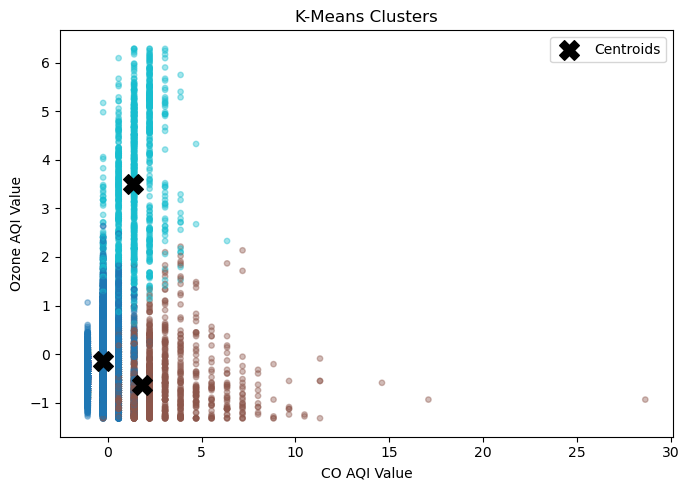

In [18]:
# Train the final K-Means model with the chosen K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_sc)
df_clean['Cluster'] = cluster_labels

print(f'Silhouette Score: {silhouette_score(X_all_sc, cluster_labels):.4f}')

# Visualize the clusters using the first two features
plt.figure(figsize=(7, 5))
plt.scatter(X_all_sc[:, 0], X_all_sc[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=15)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clusters')
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Cluster profile — average pollutant values per cluster
# This helps us understand what each cluster represents
df_clean.groupby('Cluster')[feature_cols + ['AQI Value']].mean().round(2)

,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,AQI Value
Cluster,,,,,
0,0.96,30.78,1.76,53.45,56.39
1,3.49,18.07,14.35,113.78,113.78
2,2.92,125.53,2.34,145.49,157.02



## Save Models

We save all trained models and the scaler to disk.
The FastAPI backend will load these files to serve predictions.

In [20]:
os.makedirs('models', exist_ok=True)

# Save each model and the preprocessing objects
joblib.dump(reg_results[best_reg_name]['model'], 'models/regressor.pkl')
joblib.dump(clf_results[best_clf_name]['model'], 'models/classifier.pkl')
joblib.dump(kmeans,       'models/kmeans.pkl')
joblib.dump(scaler,       'models/scaler.pkl')
joblib.dump(le,           'models/label_encoder.pkl')
joblib.dump(feature_cols, 'models/feature_cols.pkl')

print('All models saved to /models/')
print(f'  Regressor  : {best_reg_name}')
print(f'  Classifier : {best_clf_name}')
print(f'  Clustering : K-Means  K={best_k}')

All models saved to /models/
  Regressor  : Random Forest Regressor
  Classifier : Random Forest Classifier
  Clustering : K-Means  K=3



## Final Summary

In [21]:
print('=' * 55)
print('    AIR QUALITY ML PROJECT — FINAL RESULTS')
print('=' * 55)
print(f'Dataset size  : {len(df_clean):,} records')
print(f'Features used : {feature_cols}')
print()
print('[ Regression — AQI Value Prediction ]')
for name, res in reg_results.items():
    tag = '  <- BEST' if name == best_reg_name else ''
    print(f'  {name:28s}  R2={res["R2"]:.4f}  MAE={res["MAE"]:.2f}{tag}')
print()
print('[ Classification — Risk Level ]')
for name, res in clf_results.items():
    tag = '  <- BEST' if name == best_clf_name else ''
    print(f'  {name:28s}  Accuracy={res["accuracy"]:.4f}{tag}')
print()
print('[ Clustering — K-Means ]')
print(f'  K={best_k}   Silhouette Score={silhouette_score(X_all_sc, cluster_labels):.4f}')
print('=' * 55)

    AIR QUALITY ML PROJECT — FINAL RESULTS
Dataset size  : 22,974 records
Features used : ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

[ Regression — AQI Value Prediction ]
  Linear Regression             R2=0.9737  MAE=4.48
  Random Forest Regressor       R2=1.0000  MAE=0.04  <- BEST
  XGBoost Regressor             R2=0.9999  MAE=0.12

[ Classification — Risk Level ]
  Logistic Regression           Accuracy=0.9928
  Random Forest Classifier      Accuracy=1.0000  <- BEST
  SVM                           Accuracy=0.9965

[ Clustering — K-Means ]
  K=3   Silhouette Score=0.5950
